In [62]:
import pandas as pd
import numpy as np
from pathlib import Path

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [63]:
from pathlib import Path
import pandas as pd
import os

# Caminhos
PROCESSED_DIR = Path("../../../data/Airbnb Prices in European Cities/processed/")

train_path = PROCESSED_DIR / "london_treino.csv"
test_path = PROCESSED_DIR / "london_teste.csv"


df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


print(df_train.shape, df_test.shape)

(7994, 14) (1999, 14)


In [64]:
TARGET = "realSum"


X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]


X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

Função de otimização (Search Smart + K-Fold)

Para a otimização dos hiperparâmetros do XGBoost foi empregada a técnica de otimização Bayesiana (BayesSearchCV), que utiliza um modelo probabilístico para guiar a busca por configurações mais promissoras, reduzindo o custo computacional em comparação ao GridSearch exaustivo e apresentando maior eficiência do que métodos aleatórios.

In [65]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

def analise_hiperparametros(features, target):

    search_space = {
        "n_estimators": Integer(400, 800),
        "learning_rate": Real(0.05, 0.1, prior="log-uniform"),
        "max_depth": Integer(3, 8),
        "min_child_weight": Integer(1, 10),
        "subsample": Real(0.7, 1.0),
        "colsample_bytree": Real(0.7, 1.0),
        "gamma": Real(0, 1),
        "reg_alpha": Real(0, 0.5),
        "reg_lambda": Real(0.1, 10)
    }

    opt = BayesSearchCV(
        XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),
        search_spaces=search_space,
        n_iter=60,         
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    opt.fit(features, target)
    return opt


Treinamento com K-Fold COM FEATURE DAY

In [66]:
grid = analise_hiperparametros(X_train, y_train)

best_model_day = grid.best_estimator_

print("Melhores hiperparâmetros:")
print(grid.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [67]:
y_pred = best_model_day.predict(X_test)

Avaliação do modelo (Métricas)

In [68]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MSE : 0.0018
RMSE: 0.0427
R²  : 0.8616


Treinamento KFOLD SEM FEATURE DAY

In [69]:
X_train_no_day = X_train.drop(columns=["day"])
X_test_no_day  = X_test.drop(columns=["day"])

grid_no_day = analise_hiperparametros(X_train_no_day, y_train)

best_model_no_day = grid_no_day.best_estimator_

print("Melhores hiperparâmetros:")
print(grid_no_day.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [70]:
y_pred = best_model_no_day.predict(X_test_no_day)

In [71]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MSE : 0.0018
RMSE: 0.0420
R²  : 0.8659


Feature Importance 

Plot_importance nativa do XGBOOST

COM FEATURE DAY

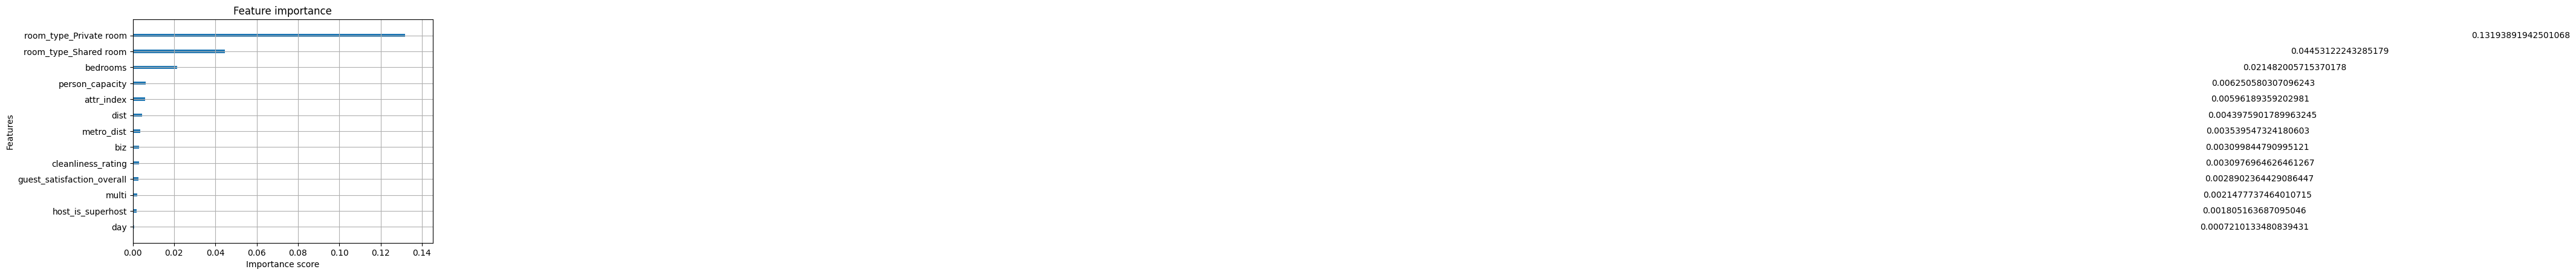

In [72]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

#usa o plot_importance nativo do xgboost
#não achei muito organizado

plot_importance(best_model_day, importance_type="gain", max_num_features=15)
plt.show()

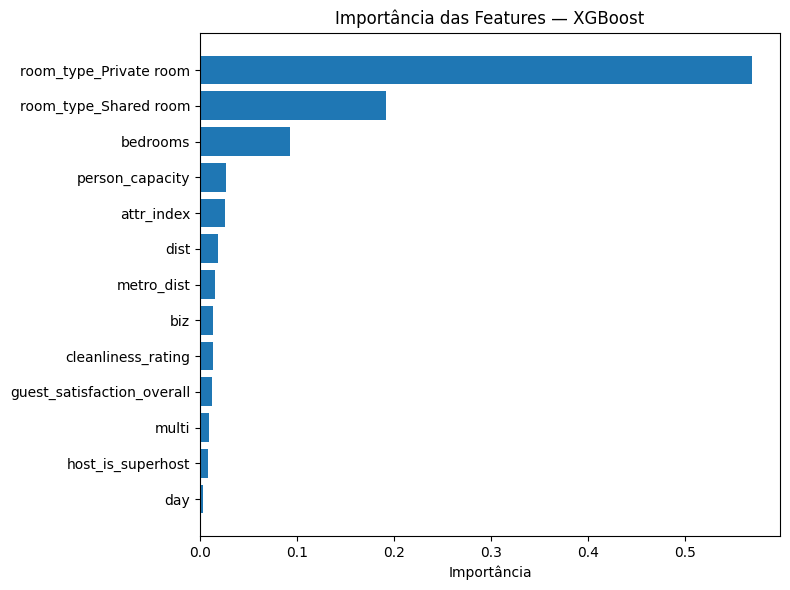

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

#mais organizado

importances = pd.Series(
    best_model_day.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importances.index[-15:], importances.values[-15:])
plt.xlabel("Importância")
plt.title("Importância das Features — XGBoost")
plt.tight_layout()
plt.show()


SEM FEATURE DAY

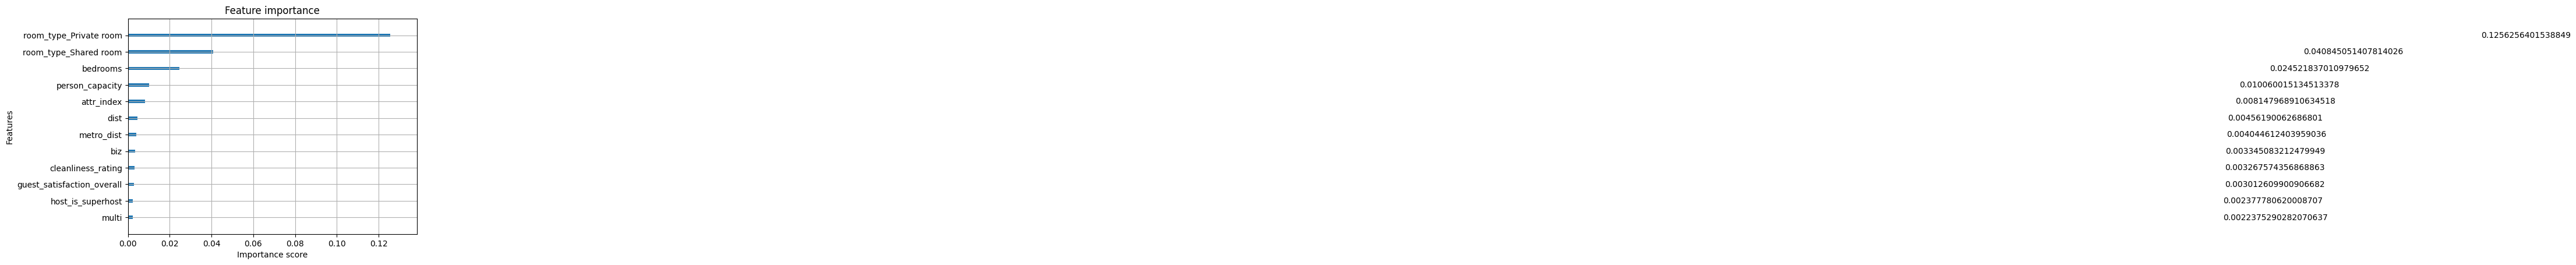

In [74]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

#usa o plot_importance nativo do xgboost
#não achei muito organizado

plot_importance(best_model_no_day, importance_type="gain", max_num_features=15)
plt.show()

Permutation Importance Comparativo

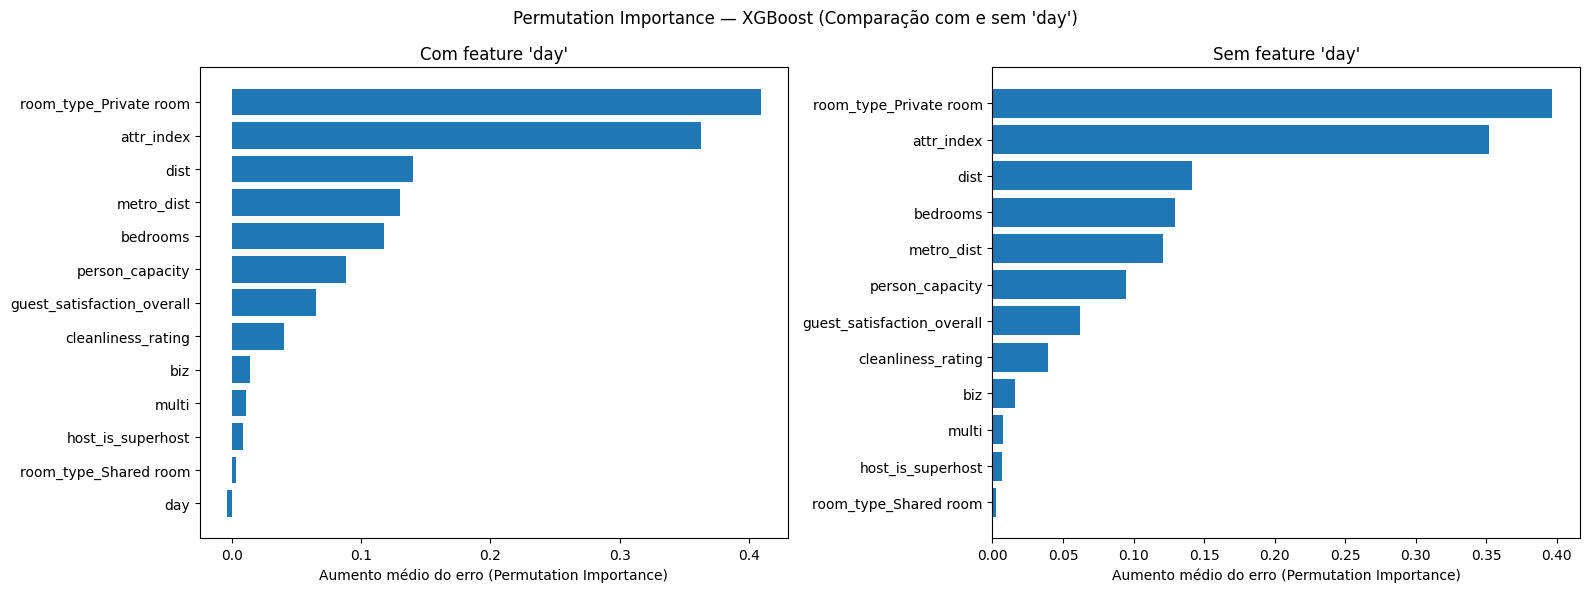

In [75]:
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
import pandas as pd

# ---------- COM day ----------
result_day = permutation_importance(
    best_model_day,
    X_test,          # contém "day"
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_day = (
    pd.Series(result_day.importances_mean, index=X_test.columns)
      .sort_values(ascending=False)
      .reset_index()
)

perm_importance_day.columns = ["feature", "importance"]


# ---------- SEM day ----------
result_no_day = permutation_importance(
    best_model_no_day,
    X_test_no_day,   # SEM "day"
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_no_day = (
    pd.Series(result_no_day.importances_mean, index=X_test_no_day.columns)
      .sort_values(ascending=False)
      .reset_index()
)

perm_importance_no_day.columns = ["feature", "importance"]


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

# ---------- COM day ----------
axes[0].barh(
    perm_importance_day["feature"][:15][::-1],
    perm_importance_day["importance"][:15][::-1]
)
axes[0].set_title("Com feature 'day'")
axes[0].set_xlabel("Aumento médio do erro (Permutation Importance)")


# ---------- SEM day ----------
axes[1].barh(
    perm_importance_no_day["feature"][:15][::-1],
    perm_importance_no_day["importance"][:15][::-1]
)
axes[1].set_title("Sem feature 'day'")
axes[1].set_xlabel("Aumento médio do erro (Permutation Importance)")


plt.suptitle("Permutation Importance — XGBoost (Comparação com e sem 'day')")
plt.tight_layout()
plt.show()
